In [1]:
import cv2

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('data'):
    if len(filenames) < 10:
        print(dirname, filenames)

data []
data/Phase1_Train_Dataset []
data/Phase1_Train_Dataset/annotations ['Cells_Anotations_coco.json']


In [3]:
import json
from collections import defaultdict

coco_path = "data/Phase1_Train_Dataset/annotations/Cells_Anotations_coco.json"

with open(coco_path, "r") as f:
    coco = json.load(f)

# map image_id -> file_name
id_to_name = {img["id"]: img["file_name"] for img in coco["images"]}

# dictionary: key = image name, value = list of all annotations for that image
annotations_by_image = defaultdict(list)

for ann in coco["annotations"]:
    img_name = id_to_name[ann["image_id"]]
    annotations_by_image[img_name].append(ann)

# make sure every image exists in dict, even if no annotations
for img in coco["images"]:
    annotations_by_image[img["file_name"]] = annotations_by_image.get(img["file_name"], [])

annotations_by_image = dict(annotations_by_image)

print("num images:", len(annotations_by_image))


num images: 1500


In [4]:
# Method A: Get the first key and its corresponding value
first_key = list(annotations_by_image.keys())[0]
print(f"First Key: {first_key}")
print(f"First Value: {annotations_by_image[first_key]}")

# Method B: Using an iterator (more memory efficient for large dicts)
first_key = next(iter(annotations_by_image))
print(first_key, annotations_by_image[first_key])

First Key: PMC1064076_6.jpg
First Value: [{'id': 1, 'image_id': 1, 'category_id': 1, 'bbox': [41.45, 165.04, 685.33, 598.82], 'area': 410389.31, 'iscrowd': 0, 'ignore': 0}, {'id': 2, 'image_id': 1, 'category_id': 6, 'bbox': [41.45, 165.04, 84.33, 79.86], 'area': 6734.59, 'iscrowd': 0, 'ignore': 0}, {'id': 3, 'image_id': 1, 'category_id': 6, 'bbox': [125.78, 165.04, 312.05, 16.59], 'area': 5176.91, 'iscrowd': 0, 'ignore': 0}, {'id': 4, 'image_id': 1, 'category_id': 6, 'bbox': [437.83, 165.04, 288.95, 16.59], 'area': 4793.68, 'iscrowd': 0, 'ignore': 0}, {'id': 5, 'image_id': 1, 'category_id': 6, 'bbox': [125.78, 181.63, 95.79, 25.54], 'area': 2446.48, 'iscrowd': 0, 'ignore': 0}, {'id': 6, 'image_id': 1, 'category_id': 6, 'bbox': [221.57, 181.63, 111.34, 25.54], 'area': 2843.62, 'iscrowd': 0, 'ignore': 0}, {'id': 7, 'image_id': 1, 'category_id': 6, 'bbox': [332.91, 181.63, 104.92, 25.54], 'area': 2679.66, 'iscrowd': 0, 'ignore': 0}, {'id': 8, 'image_id': 1, 'category_id': 6, 'bbox': [437.

In [5]:
# Check the categories defined in your JSON
for cat in coco['categories']:
    print(f"ID: {cat['id']}, Name: {cat['name']}")

ID: 1, Name: table
ID: 2, Name: table column
ID: 3, Name: table row
ID: 4, Name: table column header
ID: 5, Name: table projected row header
ID: 6, Name: table spanning cell


In [6]:
TABLE_CATEGORY_ID = 1

# Dictionary to hold the single table annotation for each valid image
single_table_only_annotations = {}

for img_name, anns in annotations_by_image.items():
    # Filter all annotations for this image to find only the 'tables'
    tables_in_image = [a for a in anns if a["category_id"] == TABLE_CATEGORY_ID]
    
    # Check if there is exactly one 'table' in this specific image
    if len(tables_in_image) == 1:
        # Save only the table annotation for training
        single_table_only_annotations[img_name] = tables_in_image

print(f"Original images: {len(annotations_by_image)}")
print(f"Images containing exactly one table: {len(single_table_only_annotations)}")

Original images: 1500
Images containing exactly one table: 1231


In [7]:
import pandas as pd

rows = []
for img_name, anns in single_table_only_annotations.items():
    # anns[0] is the only table in that image
    bbox = anns[0]['bbox'] # COCO format: [x, y, width, height]
    
    rows.append({
        "file_name": img_name,
        "x1": bbox[0],
        "y1": bbox[1],
        "x2": bbox[0] + bbox[2], # Convert width to x-max
        "y2": bbox[1] + bbox[3], # Convert height to y-max
    })

df_final = pd.DataFrame(rows)
print(f"DataFrame created with {len(df_final)} samples.")
print(df_final.head())

DataFrame created with 1231 samples.
          file_name      x1      y1      x2      y2
0  PMC1064076_6.jpg   41.45  165.04  726.78  763.86
1  PMC1079818_4.jpg   73.34  178.04  666.78  336.40
2  PMC1079918_4.jpg   73.34  130.09  649.90  234.74
3  PMC1082884_6.jpg   73.34  129.90  653.09  221.78
4  PMC1087475_6.jpg  399.01  130.09  694.39  340.49


In [8]:
from sklearn.model_selection import train_test_split

# Split into Train (80%) and a temporary set (20%)
train_df, temp_df = train_test_split(df_final, test_size=0.20, random_state=42)

# Split the temporary set into Val (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 984 | Val: 123 | Test: 124


In [9]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class SingleTableDataset(Dataset):
    def __init__(self, df, images_dir, img_size=224):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.img_size = img_size
        self.tf = T.Compose([
            T.ToPILImage(),
            T.Grayscale(num_output_channels=1),
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            # Optional: Add normalization to help regression converge
            T.Normalize(mean=[0.5], std=[0.5]) 
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        fname = row["file_name"]
        
        # Load image to get actual dimensions for normalization
        img_path = os.path.join(self.images_dir, fname)
        img = cv2.imread(img_path)
        
        if img is None:
            # Fallback for missing files
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            h, w = self.img_size, self.img_size
        else:
            h, w = img.shape[:2]
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply transformations (Grayscale + Resize)
        img_tensor = self.tf(img)

        # Normalize coordinates [x1, y1, x2, y2] to [0, 1]
        # This is critical because your model head uses a Sigmoid
        target = torch.tensor([
            row["x1"] / w, 
            row["y1"] / h, 
            row["x2"] / w, 
            row["y2"] / h
        ], dtype=torch.float32)

        return img_tensor, target

In [10]:
# Assuming images are in "data/Phase1_Train_Dataset/images"
img_dir = "data/Phase1_Train_Dataset/images"

# Initialize Datasets
train_ds = SingleTableDataset(train_df, img_dir, img_size=224)
val_ds = SingleTableDataset(val_df, img_dir, img_size=224)

# Create Loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

In [11]:
import torch
import torch.nn as nn

import torch.nn as nn

class CNN15Box(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        conv_channels = [32,32,64,64,64,128,128,128,128,256,256,256,256,256,256]
        layers, c_in = [], in_channels
        for i, c_out in enumerate(conv_channels):
            layers += [nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
                       nn.BatchNorm2d(c_out),
                       nn.ReLU(inplace=True)]
            if i in [1, 4, 8, 11, 14]:
                layers.append(nn.MaxPool2d(2))
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(conv_channels[-1], 4),
            nn.Sigmoid()  # keep outputs in [0,1]
        )

    def forward(self, x):
        return self.head(self.features(x))


In [12]:
import torch

def iou_loss(pred, target, eps=1e-6):
    """
    Custom Loss to reward overlap and penalize missed area.
    pred/target shape: [batch, 4] -> (x1, y1, x2, y2)
    """
    # 1. Determine the coordinates of the intersection rectangle
    x1 = torch.max(pred[:, 0], target[:, 0])
    y1 = torch.max(pred[:, 1], target[:, 1])
    x2 = torch.min(pred[:, 2], target[:, 2])
    y2 = torch.min(pred[:, 3], target[:, 3])

    # 2. Calculate Intersection Area
    # Use clamp(0) to handle cases with zero overlap
    inter_area = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    # 3. Calculate Individual Box Areas
    area_pred = (pred[:, 2] - pred[:, 0]) * (pred[:, 3] - pred[:, 1])
    area_gt = (target[:, 2] - target[:, 0]) * (target[:, 3] - target[:, 1])

    # 4. Calculate Union Area (Area A + Area B - Intersection)
    union_area = area_pred + area_gt - inter_area + eps

    # 5. IoU = Overlap / Total Area (Missed + Overlap)
    iou = inter_area / union_area

    # Return 1 - IoU as the loss (0 is perfect, 1 is total miss)
    return 1 - iou.mean()

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_batch(loader):
    images, targets = next(iter(loader))
    img = images[0].squeeze().numpy() # Get first image in batch
    target = targets[0].numpy() # [x1, y1, x2, y2] normalized
    
    # Denormalize for plotting (assuming 224x224)
    size = 224
    x1, y1, x2, y2 = target * size
    
    fig, ax = plt.subplots(1)
    ax.imshow(img, cmap='gray')
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    plt.title("Verify Ground Truth Box Scaling")
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
from livelossplot import PlotLosses

best_val_loss = float('inf')

def train_model(model, train_loader, val_loader, epochs=30):
    global best_val_loss
    liveloss = PlotLosses()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # 1. Training Phase
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)

            # Forward pass
            outputs = model(images)
            loss = iou_loss(outputs, targets)

            # Backward pass and optimize
            optimizer.zero_grad() 
            loss.backward()       
            optimizer.step()      

            running_loss += loss.item() * images.size(0)

        # 2. Metrics Calculation
        epoch_loss = running_loss / len(train_loader.dataset)
        val_loss, val_mean_iou = evaluate_model(model, val_loader)
        
        # 3. Checkpointing (Save Best Model)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_table_detector.pth')
            # We will pass this message to the live plot logs
            checkpoint_msg = f"Saved: {val_loss:.4f}"
        else:
            checkpoint_msg = "No improvement"

        # 4. Update Live Plots
        # We group them so 'loss' and 'val_loss' appear on the same graph
        liveloss.update({
            'loss': epoch_loss,
            'val_loss': val_loss,
            'iou': val_mean_iou
        })
        liveloss.send()
        
        print(f"Epoch {epoch+1}/{epochs} | {checkpoint_msg} | Val IoU: {val_mean_iou:.4f}")

def evaluate_model(model, loader):
    model.eval()
    running_loss = 0.0
    total_iou = 0.0
    
    with torch.no_grad(): 
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            
            # Calculate regression loss
            loss = iou_loss(outputs, targets)
            running_loss += loss.item() * images.size(0)
            
            # Calculate the actual IoU metric for reporting
            # Note: iou_loss returns (1 - IoU), so IoU = 1 - loss
            batch_iou = 1 - loss.item() 
            total_iou += batch_iou * images.size(0)
            
    mean_loss = running_loss / len(loader.dataset)
    mean_iou = total_iou / len(loader.dataset)
    return mean_loss, mean_iou

In [16]:
import torchvision.transforms as T

# Update your transforms within the Dataset or as a global variable
preprocess = T.Compose([
    T.ToPILImage(),
    T.Grayscale(num_output_channels=1), # Convert to 1-channel grayscale
    T.Resize((224, 224)),               # Reasonable dimensions for CNNs
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])   # Optional: Standardize pixel values
])

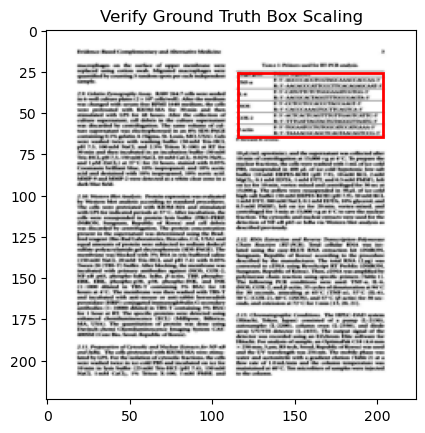

In [17]:
import torch.optim as optim

# 1. Configuration and Paths
img_dir = "data/Phase1_Train_Dataset/images"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Re-initialize DataLoaders to ensure they use the correct DataFrame
train_ds = SingleTableDataset(train_df, img_dir, img_size=224)
val_ds = SingleTableDataset(val_df, img_dir, img_size=224)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

# 3. Model Setup (Ensure in_channels=1 for grayscale)
cnn_15_layer_model = CNN15Box(in_channels=1).to(device)

# 4. Optimizer Setup (Remove the typo 'asdfa')
optimizer = optim.Adam(cnn_15_layer_model.parameters(), lr=0.0001)

# 5. Optional: Verify with a plot before starting
visualize_batch(train_loader)

In [18]:

# 6. Execute Training
train_model(
    model=cnn_15_layer_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=30
)

--> Saved better model with Val Loss: 0.8699
Epoch 1/30 - Loss: 0.7316 | Val Loss: 0.8699 | Val Mean IoU: 0.1301
--> Saved better model with Val Loss: 0.6552
Epoch 2/30 - Loss: 0.6143 | Val Loss: 0.6552 | Val Mean IoU: 0.3448
Epoch 3/30 - Loss: 0.5921 | Val Loss: 0.7533 | Val Mean IoU: 0.2467
--> Saved better model with Val Loss: 0.6032
Epoch 4/30 - Loss: 0.5760 | Val Loss: 0.6032 | Val Mean IoU: 0.3968
--> Saved better model with Val Loss: 0.5765
Epoch 5/30 - Loss: 0.5562 | Val Loss: 0.5765 | Val Mean IoU: 0.4235
Epoch 6/30 - Loss: 0.5371 | Val Loss: 0.5833 | Val Mean IoU: 0.4167
Epoch 7/30 - Loss: 0.5221 | Val Loss: 0.5938 | Val Mean IoU: 0.4062
--> Saved better model with Val Loss: 0.5311
Epoch 8/30 - Loss: 0.4970 | Val Loss: 0.5311 | Val Mean IoU: 0.4689
Epoch 9/30 - Loss: 0.4602 | Val Loss: 0.5470 | Val Mean IoU: 0.4530
--> Saved better model with Val Loss: 0.4699
Epoch 10/30 - Loss: 0.4721 | Val Loss: 0.4699 | Val Mean IoU: 0.5301
Epoch 11/30 - Loss: 0.4419 | Val Loss: 0.4850 | V

In [19]:
# Test on test_df (assumes: test_df, SingleTableDataset, CNN15Box, iou_loss are already defined)

from torch.utils.data import DataLoader
import torch

def evaluate_model(model, loader):
    model.eval()
    running_loss = 0.0
    total_iou = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)

            loss = iou_loss(outputs, targets)
            running_loss += loss.item() * images.size(0)

            batch_iou = 1 - loss.item()
            total_iou += batch_iou * images.size(0)

    mean_loss = running_loss / len(loader.dataset)
    mean_iou = total_iou / len(loader.dataset)
    return mean_loss, mean_iou

# build test loader
img_dir = "data/Phase1_Train_Dataset/images"
test_ds = SingleTableDataset(test_df, img_dir, img_size=224)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# load final model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN15Box(in_channels=1).to(device)
model.load_state_dict(torch.load("best_table_detector.pth", map_location=device))

# evaluate
test_loss, test_mean_iou = evaluate_model(model, test_loader)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Mean IoU: {test_mean_iou:.4f}")

/tmp/ipykernel_45546/3370734483.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_table_detector.pth", map_location=device))


Test Loss: 0.3225
Test Mean IoU: 0.6775
